# organize spatialdata object using 8 micron bin data

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import spatialdata as sd
import spatialdata_plot as sdp  # noqa: F401
# import squidpy as sq
from shapely.geometry import Point
from spatialdata.models import Image2DModel, ShapesModel, TableModel, Labels2DModel, PointsModel 
from tifffile import imread
import os
import re
import anndata as ad
import numpy as np
import scipy as sci
import tqdm
from spatialdata_io import visium_hd
from spatialdata.transformations import (
    set_transformation, 
    Translation,
    Scale, 
    Identity, 
    get_transformation, 
    get_transformation_between_coordinate_systems,
    Sequence)

from skimage.transform import resize

In [6]:
testid = "s105_4016S5"

In [3]:
meta = pd.read_csv("../../documents/meta_formatted_v2.csv")
meta

,ID,ID_local,Type of biopsy,Group,g1,g2,g3a,g3b,g4,Prf,cohort_exp,scrna_seq,h_e_img,seq_cohort,pull_into_integration,check,notes
0,SUR-24-6881,SUR-24-06881,Needle,Healthy liver,healthy,control,control-healthy,control-healthy,control-healthy,NaN,Not_Triumph,no,SUR-24-6881.tif,2,yes,NaN,NaN
1,SUR-22-00508,slide1_1,Needle,TC-Hep NL CD8+ Prf,disease,TC,TC-hep,TC-palf,TC-palf_nml,normal,Not_Triumph,no,577097.tif,1,no,.,NaN
2,SUR-24-03436,slide1_2,Needle,AIH,disease,AIH,control-AIH,control-AIH,AIH,NaN,Not_Triumph,no,577095.tif,1,no,.,NaN
3,SUR-21-07898,slide2_1,Explant,Disease Control,disease,control,control-disease,control-disease,Wilson,NaN,Not_Triumph,no,577091.tif,1,yes,.,NaN
4,SUR-24-05813,slide2_2,Needle,TC-Hep NL CD8+ Prf,disease,TC,TC-hep,TC-palf,TC-palf_nml,normal,Not_Triumph,no,577179.tif,1,no,.,NaN
5,SUR-24-05740,SUR-24-05740,Needle,TC-Hep High CD8+ Prf,disease,TC,TC-hep,TC-palf,TC-palf_hi,high,Not_Triumph,no,SUR-24-05740.tif,2,no,.,NaN
6,SUR-23-4044,SUR-23-04044,Needle,AIH,disease,AIH,control-AIH,control-AIH,AIH,NaN,Not_Triumph,no,SUR-23-4044.tif,2,no,.,already annotated with scPoli_3?
7,SUR-23-03188,SUR-23-03188,Explant,Disease Control,disease,control,control-disease,control-disease,Wilson,NaN,Not_Triumph,no,SUR-23-03188.tif,2,yes,.,NaN
8,SUR-24-00691,SUR-24-00691,Needle,TC-Hep High CD8+ Prf,disease,TC,TC-hep,TC-palf,TC-palf_hi,high,Not_Triumph,no,SUR-24-00691.tif,2,no,.,NaN
9,SUR-24-01502,SUR-24-01502,Needle,TC-Hep High CD8+ Prf,disease,TC,TC-hep,TC-palf,TC-palf_hi,high,Not_Triumph,no,SUR-24-01502.tif,2,no,.,NaN


In [41]:
cell_meta = pd.read_csv("../../processed/cell_meta_040226.csv", index_col=0)
cell_meta['barcode'] = cell_meta.index.map(lambda s: re.sub(r'_\d+$', '', s))
cell_meta.loc[:,"expID"] = cell_meta.expID.astype(str)
cell_meta.head()

/tmp/ipykernel_343418/383413461.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  cell_meta = pd.read_csv("../../processed/cell_meta_040226.csv", index_col=0)


,nCount_Spatial,nFeature_Spatial,cohort,cohort_bio,cohort_biopsy_type,expID,orig.ident,group,Annotations,Annotations_lvl2,...,seu_pred_anno_lvl1,seu_pred_anno_lvl2,consensus_lvl1,consensus_lvl2_simpl,azi_pct_anno,td_pct_anno,AUCell_pred_t,AUCell_pred_az,ct_lvl1_final,barcode
s_008um_00304_00136-1_1,382,335,cohort1,Not_Triumph,Needle,SUR-22-00508,slide1_1,TC-Hep NL CD8+ Prf,unknown,unknown,...,Cholangiocytes,Cholangiocytes,Cholangiocytes,Cholangiocytes,Myeloid,Myeloid.filter,B-cells,Cholangiocytes,T-cells,s_008um_00304_00136-1
s_008um_00693_00628-1_1,172,155,cohort1,Not_Triumph,Needle,SUR-22-00508,slide1_1,TC-Hep NL CD8+ Prf,unknown,unknown,...,Hepatocyte,Hepatocyte_Z1_2,Hepatocyte,Hepatocyte,Hepatocyte,HSC_fibroblasts.markers.filter,T-cells,Plasma_cells,Plasma_cells,s_008um_00693_00628-1
s_008um_00129_00000-1_1,222,203,cohort1,Not_Triumph,Needle,SUR-22-00508,slide1_1,TC-Hep NL CD8+ Prf,unknown,unknown,...,Fibroblasts,HSC_fibroblasts,Fibroblasts,Fibroblasts,Fibroblasts,Fibroblasts,Fibroblasts,Fibroblasts,Fibroblasts,s_008um_00129_00000-1
s_008um_00660_00606-1_1,214,180,cohort1,Not_Triumph,Needle,SUR-22-00508,slide1_1,TC-Hep NL CD8+ Prf,unknown,unknown,...,Hepatocyte,Hepatocyte_Z1_2,B-cells,B-cells,B-cells,B-cells,B-cells,B-cells,B-cells,s_008um_00660_00606-1
s_008um_00474_00251-1_1,212,194,cohort1,Not_Triumph,Needle,SUR-22-00508,slide1_1,TC-Hep NL CD8+ Prf,unknown,unknown,...,Hepatocyte,Hepatocyte_Z3,Plasma_cells,Plasma_cells,Plasma_cells,Plasma_cells,Plasma_cells,Plasma_cells,Plasma_cells,s_008um_00474_00251-1


In [7]:
sdata = visium_hd("../01-SpaceRanger_cohort2/s105_4016S5/outs/",
                  dataset_id=testid,
                  bin_size=8,
                 fullres_image_file="../03-segmentation/stardist/s105_4016S5he.tiff") 
sdata # doesn't look like the H&E was included

/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


SpatialData object
├── Images
│     ├── 's105_4016S5_full_image': DataTree[cyx] (3, 13620, 13698), (3, 6810, 6849), (3, 3405, 3424), (3, 1702, 1712), (3, 851, 856)
│     ├── 's105_4016S5_hires_image': DataArray[cyx] (3, 3248, 6000)
│     └── 's105_4016S5_lowres_image': DataArray[cyx] (3, 325, 600)
├── Shapes
│     └── 's105_4016S5_square_008um': GeoDataFrame shape: (116974, 1) (2D shapes)
└── Tables
      └── 'square_008um': AnnData (116974, 18085)
with coordinate systems:
    ▸ 's105_4016S5', with elements:
        s105_4016S5_full_image (Images), s105_4016S5_hires_image (Images), s105_4016S5_lowres_image (Images), s105_4016S5_square_008um (Shapes)
    ▸ 's105_4016S5_downscaled_hires', with elements:
        s105_4016S5_hires_image (Images), s105_4016S5_square_008um (Shapes)
    ▸ 's105_4016S5_downscaled_lowres', with elements:
        s105_4016S5_lowres_image (Images), s105_4016S5_square_008um (Shapes)

In [9]:
sdata['square_008um'].obs

,in_tissue,array_row,array_col,location_id,region
s_008um_00725_00831-1,1,725,831,0,s105_4016S5_square_008um
s_008um_00693_00628-1,1,693,628,1,s105_4016S5_square_008um
s_008um_00660_00606-1,1,660,606,2,s105_4016S5_square_008um
s_008um_00474_00251-1,1,474,251,3,s105_4016S5_square_008um
s_008um_00622_00588-1,1,622,588,4,s105_4016S5_square_008um
...,...,...,...,...,...
s_008um_00700_00830-1,1,700,830,116969,s105_4016S5_square_008um
s_008um_00636_00440-1,1,636,440,116970,s105_4016S5_square_008um
s_008um_00474_00285-1,1,474,285,116971,s105_4016S5_square_008um
s_008um_00426_00125-1,1,426,125,116972,s105_4016S5_square_008um


INFO     Dropping coordinate system 's105_4016S5_downscaled_lowres' since it doesn't have relevant elements.       
INFO     Dropping coordinate system 's105_4016S5_downscaled_hires' since it doesn't have relevant elements.        


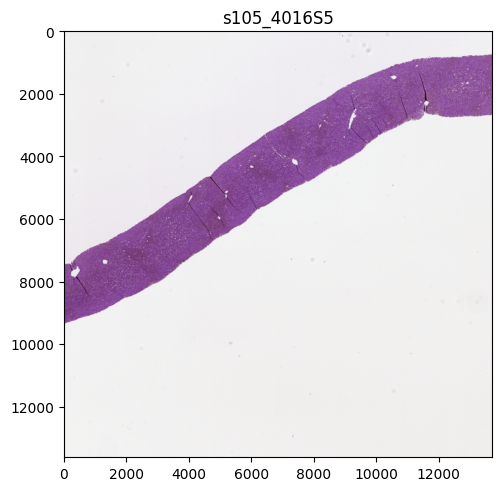

In [6]:
sdata.pl.render_images("s105_4016S5_full_image").pl.show()

# Add H&E

In [5]:
img = imread("../03-segmentation/stardist/"+testid+"he.tiff")
img = np.transpose(img, (2,0,1))
img_for_sdata = Image2DModel.parse(data=img, scale_factors=(2, 2, 2), c_coords=["r", "g", "b"]) # this creates 4 downscaled images as well


INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           


In [6]:
sdata['h_and_e'] = img_for_sdata
sdata

SpatialData object
├── Images
│     ├── 'h_and_e': DataTree[cyx] (3, 13620, 13698), (3, 6810, 6849), (3, 3405, 3424), (3, 1702, 1712)
│     ├── 's105_4016S5_full_image': DataTree[cyx] (3, 13620, 13698), (3, 6810, 6849), (3, 3405, 3424), (3, 1702, 1712), (3, 851, 856)
│     ├── 's105_4016S5_hires_image': DataArray[cyx] (3, 3248, 6000)
│     └── 's105_4016S5_lowres_image': DataArray[cyx] (3, 325, 600)
├── Shapes
│     └── 's105_4016S5_square_008um': GeoDataFrame shape: (116974, 1) (2D shapes)
└── Tables
      └── 'square_008um': AnnData (116974, 18085)
with coordinate systems:
    ▸ 'global', with elements:
        h_and_e (Images)
    ▸ 's105_4016S5', with elements:
        s105_4016S5_full_image (Images), s105_4016S5_hires_image (Images), s105_4016S5_lowres_image (Images), s105_4016S5_square_008um (Shapes)
    ▸ 's105_4016S5_downscaled_hires', with elements:
        s105_4016S5_hires_image (Images), s105_4016S5_square_008um (Shapes)
    ▸ 's105_4016S5_downscaled_lowres', with elements:

In [7]:
# translate the images
adata = ad.read_h5ad("../03-segmentation/seg_nuclei/bin2cell/"+testid+".h5ad")
adata

AnnData object with n_obs × n_vars = 94777 × 17162
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'Absolute.X', 'Absolute.Y', 'cropped.X', 'cropped.Y'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'

In [8]:
x_trans = adata.obsm['spatial'][:,0].min() - adata.obsm['spatial_cropped_150_buffer'][:,0].min()
y_trans = adata.obsm['spatial'][:,1].min() - adata.obsm['spatial_cropped_150_buffer'][:,1].min()

In [9]:
coords_backup = get_transformation(sdata['h_and_e'])
shift_img = Translation([x_trans, y_trans], axes=("x","y"))
shift_sequence = Sequence([coords_backup, shift_img])
set_transformation(sdata['h_and_e'], shift_sequence, "s105_4016S5")

# Add metadata

In [10]:
meta = pd.read_csv('test_meta.csv', index_col="Barcode")
meta.head()

,orig.ident,nCount_RNA,nFeature_RNA,nCount_Spatial,nFeature_Spatial,percent.mt,percent.rps,leverage.score,cohort,leverage.score.1,...,expID,group,predicted.id,prediction.score.max,predicted.id.full,predicted.id.full.score,Annotations,Annotations_simpl,hep_score1,Annotations_2
Barcode,,,,,,,,,,,,,,,,,,,,,
s_008um_00725_00831-1,s105_4016S5,285,246,285,246,0,0,NaN,cohort2,0.019712,...,105,TC-PALF high CD8+ prf,NaN,NaN,T cell,0.479218,T-cells,T-cells,0.074774,T-cells_0
s_008um_00693_00628-1,s105_4016S5,166,152,166,152,0,0,NaN,cohort2,0.325499,...,105,TC-PALF high CD8+ prf,endothelial cell of hepatic sinusoid,0.294579,endothelial cell of hepatic sinusoid,0.444136,Myeloid_KC_1,Myeloid_KC_1,0.519119,Myeloid_KC_1
s_008um_00660_00606-1,s105_4016S5,213,184,213,184,0,0,NaN,cohort2,0.010795,...,105,TC-PALF high CD8+ prf,NaN,NaN,Kupffer cell,0.919281,NaN,NaN,0.195237,NaN
s_008um_00474_00251-1,s105_4016S5,236,206,236,206,0,0,NaN,cohort2,0.008510,...,105,TC-PALF high CD8+ prf,NaN,NaN,hepatocyte,0.693945,Myeloid_KC_1,Myeloid_KC_1,0.707708,Myeloid_KC_1
s_008um_00622_00588-1,s105_4016S5,378,332,378,332,0,0,NaN,cohort2,0.017361,...,105,TC-PALF high CD8+ prf,NaN,NaN,Kupffer cell,0.715242,Myeloid_KC_1,Myeloid_KC_1,0.344158,Myeloid_KC_1


In [11]:
keep_cols = ['nCount_RNA','nFeature_RNA','percent.mt','predicted.id.full','Annotations','hep_score1','Annotations_2']
new_meta = sdata['square_008um'].obs.join(meta.loc[:,keep_cols])
print(new_meta.shape)
new_meta.head()

(116974, 12)


,in_tissue,array_row,array_col,location_id,region,nCount_RNA,nFeature_RNA,percent.mt,predicted.id.full,Annotations,hep_score1,Annotations_2
s_008um_00725_00831-1,1,725,831,0,s105_4016S5_square_008um,285.0,246.0,0.0,T cell,T-cells,0.074774,T-cells_0
s_008um_00693_00628-1,1,693,628,1,s105_4016S5_square_008um,166.0,152.0,0.0,endothelial cell of hepatic sinusoid,Myeloid_KC_1,0.519119,Myeloid_KC_1
s_008um_00660_00606-1,1,660,606,2,s105_4016S5_square_008um,213.0,184.0,0.0,Kupffer cell,NaN,0.195237,NaN
s_008um_00474_00251-1,1,474,251,3,s105_4016S5_square_008um,236.0,206.0,0.0,hepatocyte,Myeloid_KC_1,0.707708,Myeloid_KC_1
s_008um_00622_00588-1,1,622,588,4,s105_4016S5_square_008um,378.0,332.0,0.0,Kupffer cell,Myeloid_KC_1,0.344158,Myeloid_KC_1


In [12]:
sdata['square_008um'].obs = new_meta

In [13]:
sdata['square_008um'].obs['Annotations_2'] = sdata['square_008um'].obs['Annotations_2'].astype('category')
sdata['square_008um'].obs['Annotations'] = sdata['square_008um'].obs['Annotations'].astype('category')
sdata['square_008um'].obs['predicted.id.full'] = sdata['square_008um'].obs['predicted.id.full'].astype('category')

In [22]:
sdata['square_008um'].uns

OrderedDict([('spatialdata_attrs',
              {'region': 's105_4016S5_square_008um',
               'region_key': 'region',
               'instance_key': 'location_id'})])

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `s105_4016S5_square_008um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `square_008um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata_plot/pl/utils.py:800: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


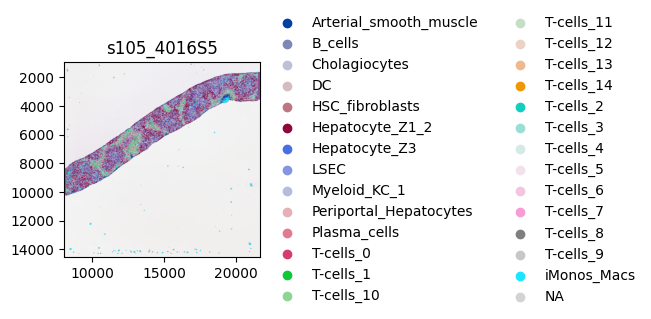

In [43]:
sdata.pl.render_images('h_and_e').pl.render_shapes('s105_4016S5_square_008um', color='Annotations_2').pl.show(coordinate_systems=["s105_4016S5"])

# add the segmentation mask

In [14]:
labels = sci.sparse.load_npz("../03-segmentation/stardist/"+testid+".npz")
labels = labels.toarray()
labels = labels.astype(int)

seg_img = np.zeros_like(labels)
seg_img[labels > 0] = 255
seg_img = np.expand_dims(seg_img, axis=0)

In [15]:
seg_for_sdata = Image2DModel.parse(data=seg_img, scale_factors=(2, 2, 2))  # this creates 4 downscaled images as well
sdata['nuclei_seg_mask'] = seg_for_sdata
coords_backup = get_transformation(sdata['nuclei_seg_mask'])
shift_img = Translation([x_trans, y_trans], axes=("x","y"))
shift_sequence = Sequence([coords_backup, shift_img])
set_transformation(sdata['nuclei_seg_mask'], shift_sequence, "s105_4016S5")

INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `s105_4016S5_square_008um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `square_008um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata_plot/pl/utils.py:800: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


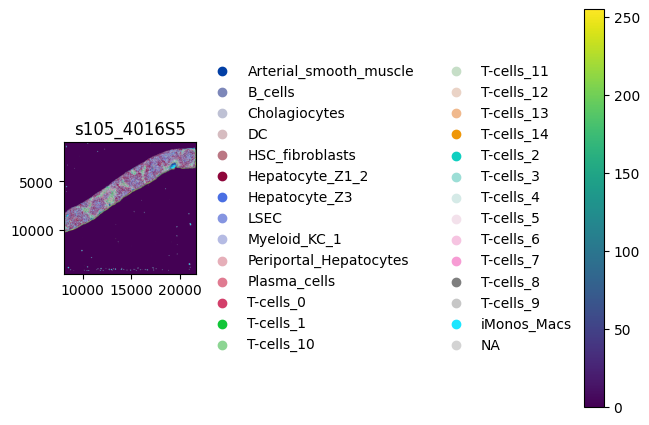

In [54]:
sdata.pl.render_images('nuclei_seg_mask').pl.render_shapes('s105_4016S5_square_008um', color='Annotations_2').pl.show(coordinate_systems=["s105_4016S5"])

## Make labels

I think I need to force polygon index to string...

match the order of polygons and table

In [16]:
img_name = next(iter(sdata.images.data.keys()))
poly_name = next(iter(sdata.shapes.data.keys()))
max_x, max_y = sdata[img_name]["scale0"].dims['x'], sdata[img_name]["scale0"].dims['y']


In [17]:
sdata[poly_name].index = sdata[poly_name].index.astype(str) 
sdata['square_008um'].obs['location_id'] = sdata['square_008um'].obs['location_id'].astype(str)

In [18]:
location_cat = pd.Categorical(sdata['square_008um'].obs['location_id'].values, ordered=False)
location_cat.codes

array([    0,     1, 28086, ..., 18860, 18861, 18862],
      shape=(116974,), dtype=int32)

In [19]:
sdata['square_008um'].obs['new_instanceID'] = location_cat.codes+1

In [78]:
## only run if need to redo

# del sdata['bin_labels_int']
# sdata["square_008um"].obs["region"] = poly_name
# sdata.set_table_annotates_spatialelement("square_008um", region=poly_name, instance_key="location_id")

In [20]:
labs = sd.rasterize(sdata[poly_name],
                            ["x", "y"],
                            min_coordinate=[0+x_trans, 0+y_trans],
                            max_coordinate=[max_x+x_trans, max_y+y_trans],
                            target_coordinate_system="s105_4016S5",
                            target_unit_to_pixels=1.0,
                            return_regions_as_labels=False)

In [21]:
labs = labs.astype(int)

In [22]:
# sdata['bin_labels_int'] = sd.models.Labels2DModel.parse(labs[0], scale_factors=(2, 2, 2))
sdata['bin_labels_int'] = sd.models.Labels2DModel.parse(labs[0])

In [23]:
label_dict = {i+1:i+1 for i in range(sdata[poly_name].shape[0])}
sdata['bin_labels_int'].attrs['label_index_to_category'] = label_dict


In [24]:
sdata["square_008um"].obs["region"] = "bin_labels_int"
sdata.set_table_annotates_spatialelement("square_008um", region="bin_labels_int", instance_key="new_instanceID")

/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     Rasterizing image for faster rendering.                                                                   


/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata_plot/pl/utils.py:800: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


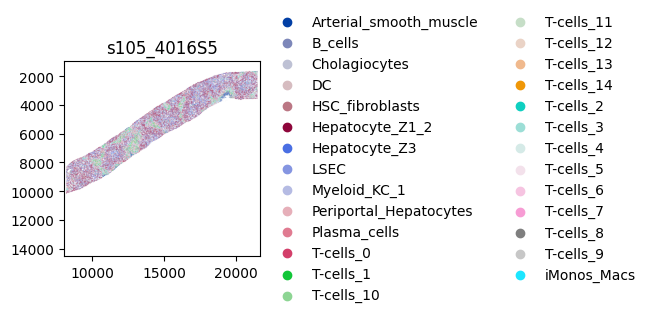

In [78]:
sdata.pl.render_labels('bin_labels_int', color='Annotations_2').pl.show(coordinate_systems=["s105_4016S5"])

## Add points

In [38]:
# del sdata['grid_points']

In [25]:
poly_c = sdata['s105_4016S5_square_008um'].geometry.centroid
dat_points = np.array([p.coords[0] for p in poly_c])
# point_anno = pd.DataFrame({"grid_entity":sdata['square_008um'].obs['new_instanceID'].values,
#                           "orig_id":sdata['square_008um'].obs['location_id'].values})
sdata['grid_points'] = PointsModel.parse(dat_points, annotation=sdata['square_008um'].obs, instance_key="new_instanceID")
sdata

SpatialData object
├── Images
│     ├── 'h_and_e': DataTree[cyx] (3, 13620, 13698), (3, 6810, 6849), (3, 3405, 3424), (3, 1702, 1712)
│     ├── 'nuclei_seg_mask': DataTree[cyx] (1, 13620, 13698), (1, 6810, 6849), (1, 3405, 3424), (1, 1702, 1712)
│     ├── 's105_4016S5_full_image': DataTree[cyx] (3, 13620, 13698), (3, 6810, 6849), (3, 3405, 3424), (3, 1702, 1712), (3, 851, 856)
│     ├── 's105_4016S5_hires_image': DataArray[cyx] (3, 3248, 6000)
│     └── 's105_4016S5_lowres_image': DataArray[cyx] (3, 325, 600)
├── Labels
│     └── 'bin_labels_int': DataArray[yx] (13620, 13698)
├── Points
│     └── 'grid_points': DataFrame with shape: (<Delayed>, 15) (2D points)
├── Shapes
│     └── 's105_4016S5_square_008um': GeoDataFrame shape: (116974, 1) (2D shapes)
└── Tables
      └── 'square_008um': AnnData (116974, 18085)
with coordinate systems:
    ▸ 'global', with elements:
        h_and_e (Images), nuclei_seg_mask (Images), grid_points (Points)
    ▸ 's105_4016S5', with elements:
        h_an

In [26]:
coords_backup = get_transformation(sdata['grid_points'])
# shift_img = Translation([x_trans, y_trans], axes=("x","y"))
# shift_sequence = Sequence([coords_backup, shift_img])
set_transformation(sdata['grid_points'], coords_backup, "s105_4016S5")

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/_elements.py:118: UserWarning: Key `grid_points` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata_plot/pl/utils.py:800: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seein

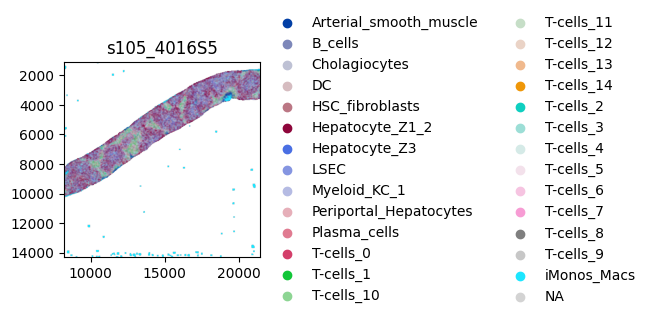

In [27]:
sdata.pl.render_points('grid_points', color='Annotations_2').pl.show(coordinate_systems=["s105_4016S5"])

## Downsize everything

h&e, seg_mask, labels, (and points?)

In [28]:
coords_backup = get_transformation(sdata["h_and_e"], to_coordinate_system="global")
downscale = Scale([1/4, 1/4], axes=("x","y"))
down_sequence = Sequence([coords_backup, downscale])
set_transformation(sdata['h_and_e'], down_sequence, "lo_res")

In [29]:
coords_backup = get_transformation(sdata["nuclei_seg_mask"], to_coordinate_system="global")
downscale = Scale([1/4, 1/4], axes=("x","y"))
down_sequence = Sequence([coords_backup, downscale])
set_transformation(sdata['nuclei_seg_mask'], down_sequence, "lo_res")

In [79]:
# del sdata['bin_labels_int_lores']

In [30]:
arr = sdata["bin_labels_int"].data.compute()
scale = 0.25
new_shape = (int(arr.shape[0] * scale), int(arr.shape[1] * scale))
down_label = resize(
    arr,
    new_shape,
    order=0,        # nearest neighbor: crucial for labels
    anti_aliasing=False,
    preserve_range=True
).astype(arr.dtype)
sdata["bin_labels_int_lores"] = sd.models.Labels2DModel.parse(down_label)
coords_backup = get_transformation(sdata["bin_labels_int_lores"])
set_transformation(sdata['bin_labels_int_lores'], coords_backup, "lo_res")

INFO     no axes information specified in the object, setting `dims` to: ('y', 'x')                                


In [31]:
label_dict = {i+1:i+1 for i in range(sdata[poly_name].shape[0])}
sdata['bin_labels_int_lores'].attrs['label_index_to_category'] = label_dict

In [32]:
sdata["square_008um"].obs["region"] = "bin_labels_int_lores"
sdata.set_table_annotates_spatialelement("square_008um", region="bin_labels_int_lores", instance_key="new_instanceID")

/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


INFO     Rasterizing image for faster rendering.                                                                   


/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata_plot/pl/utils.py:800: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


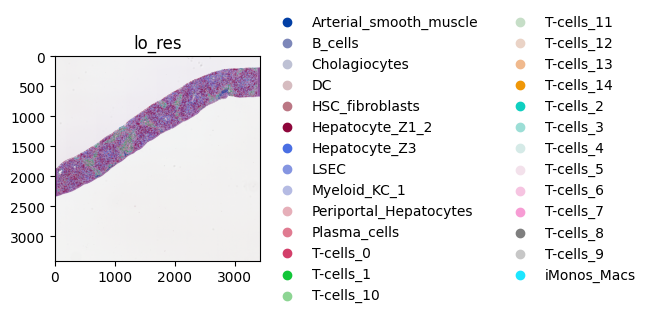

In [35]:
sdata.pl.render_images('h_and_e').pl.render_labels('bin_labels_int_lores', color='Annotations_2').pl.show(coordinate_systems=["lo_res"])
# sdata.pl.render_images('h_and_e').pl.show(coordinate_systems=["lo_res"])

## Shrinking the points

In [39]:
get_transformation(sdata["grid_points"])

Identity 

In [33]:
coords_backup = get_transformation(sdata["grid_points"])
downscale = Scale([1/4, 1/4], axes=("x","y"))
shift_img = Translation([-1*x_trans, -1*y_trans], axes=("x","y"))
down_sequence = Sequence([coords_backup, shift_img, downscale])
set_transformation(sdata['grid_points'], down_sequence, "lo_res")

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/_elements.py:118: UserWarning: Key `grid_points` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata_plot/pl/utils.py:800: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seein

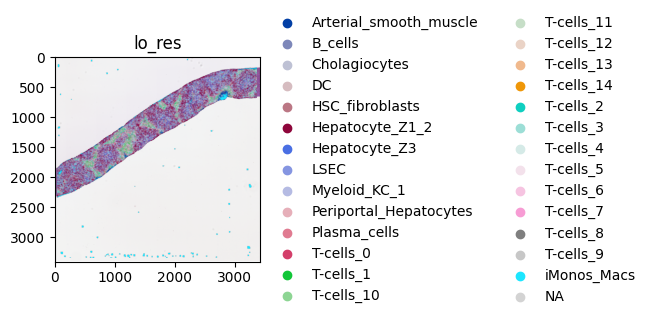

In [34]:
sdata.pl.render_images('h_and_e').pl.render_points('grid_points', color='Annotations_2').pl.show(coordinate_systems=["lo_res"])


In [29]:
sdata

SpatialData object
├── Images
│     ├── 's105_4016S5_full_image': DataTree[cyx] (3, 13620, 13698), (3, 6810, 6849), (3, 3405, 3424), (3, 1702, 1712), (3, 851, 856)
│     ├── 's105_4016S5_hires_image': DataArray[cyx] (3, 3248, 6000)
│     └── 's105_4016S5_lowres_image': DataArray[cyx] (3, 325, 600)
├── Shapes
│     └── 's105_4016S5_square_008um': GeoDataFrame shape: (116974, 1) (2D shapes)
└── Tables
      └── 'square_008um': AnnData (116974, 18085)
with coordinate systems:
    ▸ 's105_4016S5', with elements:
        s105_4016S5_full_image (Images), s105_4016S5_hires_image (Images), s105_4016S5_lowres_image (Images), s105_4016S5_square_008um (Shapes)
    ▸ 's105_4016S5_downscaled_hires', with elements:
        s105_4016S5_hires_image (Images), s105_4016S5_square_008um (Shapes)
    ▸ 's105_4016S5_downscaled_lowres', with elements:
        s105_4016S5_lowres_image (Images), s105_4016S5_square_008um (Shapes)

# save it

In [35]:
sdata['square_008um'] = sdata['square_008um'][~sdata['square_008um'].obs['Annotations_2'].isna(),:]
sdata

/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `square_008um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


SpatialData object
├── Images
│     ├── 'h_and_e': DataTree[cyx] (3, 13620, 13698), (3, 6810, 6849), (3, 3405, 3424), (3, 1702, 1712)
│     ├── 'nuclei_seg_mask': DataTree[cyx] (1, 13620, 13698), (1, 6810, 6849), (1, 3405, 3424), (1, 1702, 1712)
│     ├── 's105_4016S5_full_image': DataTree[cyx] (3, 13620, 13698), (3, 6810, 6849), (3, 3405, 3424), (3, 1702, 1712), (3, 851, 856)
│     ├── 's105_4016S5_hires_image': DataArray[cyx] (3, 3248, 6000)
│     └── 's105_4016S5_lowres_image': DataArray[cyx] (3, 325, 600)
├── Labels
│     ├── 'bin_labels_int': DataArray[yx] (13620, 13698)
│     └── 'bin_labels_int_lores': DataArray[yx] (3405, 3424)
├── Points
│     └── 'grid_points': DataFrame with shape: (<Delayed>, 15) (2D points)
├── Shapes
│     └── 's105_4016S5_square_008um': GeoDataFrame shape: (116974, 1) (2D shapes)
└── Tables
      └── 'square_008um': AnnData (111218, 18085)
with coordinate systems:
    ▸ 'global', with elements:
        h_and_e (Images), nuclei_seg_mask (Images), bin_labe

In [96]:
sdata['square_008um'].obs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111218 entries, s_008um_00725_00831-1 to s_008um_00426_00125-1
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   in_tissue          111218 non-null  uint8   
 1   array_row          111218 non-null  uint32  
 2   array_col          111218 non-null  uint32  
 3   location_id        111218 non-null  object  
 4   region             111218 non-null  category
 5   nCount_RNA         111218 non-null  float64 
 6   nFeature_RNA       111218 non-null  float64 
 7   percent.mt         111218 non-null  float64 
 8   predicted.id.full  111218 non-null  category
 9   Annotations        111218 non-null  category
 10  hep_score1         111218 non-null  float64 
 11  Annotations_2      111218 non-null  category
 12  new_instanceID     111218 non-null  int32   
dtypes: category(4), float64(4), int32(1), object(1), uint32(2), uint8(1)
memory usage: 6.9+ MB


In [36]:
sdata.write("s105_8u_bins_lores.zarr", overwrite=True)

INFO     The Zarr backing store has been changed from None the new file path: s105_8u_bins_lores.zarr              


In [89]:
sdata['bin_labels_int'].attrs.keys()

dict_keys(['x_range', 'y_range', 'label_index_to_category', 'transform'])

In [37]:
sdata2 = sd.read_zarr("s105_8u_bins.zarr/")
sdata2

version mismatch: detected: RasterFormatV02, requested: FormatV04
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'


SpatialData object, with associated Zarr store: /mnt/isilon/cscb/Projects/10x_Visium/diamondt/SCTC-TD-253/code/05-EDA/s105_8u_bins.zarr
├── Images
│     ├── 'h_and_e': DataTree[cyx] (3, 13620, 13698), (3, 6810, 6849), (3, 3405, 3424), (3, 1702, 1712)
│     ├── 'nuclei_seg_mask': DataTree[cyx] (1, 13620, 13698), (1, 6810, 6849), (1, 3405, 3424), (1, 1702, 1712)
│     ├── 's105_4016S5_full_image': DataTree[cyx] (3, 13620, 13698), (3, 6810, 6849), (3, 3405, 3424), (3, 1702, 1712), (3, 851, 856)
│     ├── 's105_4016S5_hires_image': DataArray[cyx] (3, 3248, 6000)
│     └── 's105_4016S5_lowres_image': DataArray[cyx] (3, 325, 600)
├── Shapes
│     └── 's105_4016S5_square_008um': GeoDataFrame shape: (116974, 1) (2D shapes)
└── Tables
      └── 'square_008um': AnnData (111218, 18085)
with coordinate systems:
    ▸ 'global', with elements:
        h_and_e (Images), nuclei_seg_mask (Images)
    ▸ 's105_4016S5', with elements:
        h_and_e (Images), nuclei_seg_mask (Images), s105_4016S5_full_im

In [39]:
sdata2['s105_4016S5_square_008um'].head()

,geometry
location_id,
0,"POLYGON ((21381.358 2782.904, 21381.358 2767.0..."
1,"POLYGON ((18154.925 3290.885, 18154.925 3274.9..."
2,"POLYGON ((17805.176 3815.313, 17805.176 3799.4..."
3,"POLYGON ((12162.487 6770.484, 12162.487 6754.5..."
4,"POLYGON ((17518.986 4419.222, 17518.986 4403.3..."


# Running all samples

In [42]:
for testid in tqdm.tqdm(meta.ID_local.values):
    # if os.path.isdir("../../processed/spatialdata/binned/"+testid+"_lores.zarr"):
    #     continue
    print(testid)
    if "slide" in testid:
        sdata = visium_hd("../01-SpaceRanger/"+testid+"/outs/",
                      dataset_id=testid,
                      bin_size=8,
                     fullres_image_file="../03-segmentation/stardist/"+testid+"he.tiff") 
    else:
        sdata = visium_hd("../01-SpaceRanger_cohort2/"+testid+"/outs/",
                      dataset_id=testid,
                      bin_size=8,
                     fullres_image_file="../03-segmentation/stardist/"+testid+"he.tiff") 
    # H&E
    print("reading H&E...")
    img = imread("../03-segmentation/stardist/"+testid+"he.tiff")
    img = np.transpose(img, (2,0,1))
    img_for_sdata = Image2DModel.parse(data=img, scale_factors=(2, 2, 2), c_coords=["r", "g", "b"]) # this creates 4 downscaled images as well
    sdata['h_and_e'] = img_for_sdata
    adata = ad.read_h5ad("../03-segmentation/seg_dilate_2/bin2cell/"+testid+".h5ad")
    x_trans = adata.obsm['spatial'][:,0].min() - adata.obsm['spatial_cropped_150_buffer'][:,0].min()
    y_trans = adata.obsm['spatial'][:,1].min() - adata.obsm['spatial_cropped_150_buffer'][:,1].min()
    coords_backup = get_transformation(sdata['h_and_e'])
    shift_img = Translation([x_trans, y_trans], axes=("x","y"))
    shift_sequence = Sequence([coords_backup, shift_img])
    set_transformation(sdata['h_and_e'], shift_sequence, testid)
    # add metadata
    meta_s = cell_meta.loc[cell_meta['orig.ident']==testid]
    meta_s.set_index("barcode", inplace=True)
    meta_s.index.name = None
    new_meta = sdata['square_008um'].obs.join(meta_s)
    sdata['square_008um'].obs = new_meta
    sdata["square_008um"].obs.loc[sdata["square_008um"].obs["cohort_biopsy_type"].isna(),"cohort_biopsy_type"] = "unknown"
    # make labels
    print("making labels...")
    img_name = next(iter(sdata.images.data.keys()))
    poly_name = next(iter(sdata.shapes.data.keys()))
    max_x, max_y = sdata[img_name]["scale0"].dims['x'], sdata[img_name]["scale0"].dims['y']
    sdata[poly_name].index = sdata[poly_name].index.astype(str) 
    sdata['square_008um'].obs['location_id'] = sdata['square_008um'].obs['location_id'].astype(str)
    location_cat = pd.Categorical(sdata['square_008um'].obs['location_id'].values, ordered=False)
    sdata['square_008um'].obs['new_instanceID'] = location_cat.codes+1
    labs = sd.rasterize(sdata[poly_name],
                            ["x", "y"],
                            min_coordinate=[0+x_trans, 0+y_trans],
                            max_coordinate=[max_x+x_trans, max_y+y_trans],
                            target_coordinate_system=testid,
                            target_unit_to_pixels=1.0,
                            return_regions_as_labels=False)
    labs = labs.astype(int)
    sdata['bin_labels_int'] = sd.models.Labels2DModel.parse(labs[0])
    label_dict = {i+1:i+1 for i in range(sdata[poly_name].shape[0])}
    sdata['bin_labels_int'].attrs['label_index_to_category'] = label_dict
    sdata["square_008um"].obs["region"] = "bin_labels_int"
    sdata.set_table_annotates_spatialelement("square_008um", region="bin_labels_int", instance_key="new_instanceID")
    # add points
    print("making points...")
    poly_c = sdata[poly_name].geometry.centroid
    dat_points = np.array([p.coords[0] for p in poly_c])
    sdata['grid_points'] = PointsModel.parse(dat_points, annotation=sdata['square_008um'].obs, instance_key="new_instanceID")
    coords_backup = get_transformation(sdata['grid_points'])
    set_transformation(sdata['grid_points'], coords_backup, testid)
    # downsize
    print("downsizing...")
    coords_backup = get_transformation(sdata["h_and_e"], to_coordinate_system="global")
    downscale = Scale([1/4, 1/4], axes=("x","y"))
    down_sequence = Sequence([coords_backup, downscale])
    set_transformation(sdata['h_and_e'], down_sequence, "lo_res")
    arr = sdata["bin_labels_int"].data.compute()
    scale = 0.25
    new_shape = (int(arr.shape[0] * scale), int(arr.shape[1] * scale))
    down_label = resize(
        arr,
        new_shape,
        order=0,        # nearest neighbor: crucial for labels
        anti_aliasing=False,
        preserve_range=True
    ).astype(arr.dtype)
    sdata["bin_labels_int_lores"] = sd.models.Labels2DModel.parse(down_label)
    coords_backup = get_transformation(sdata["bin_labels_int_lores"])
    set_transformation(sdata['bin_labels_int_lores'], coords_backup, "lo_res")
    label_dict = {i+1:i+1 for i in range(sdata[poly_name].shape[0])}
    sdata['bin_labels_int_lores'].attrs['label_index_to_category'] = label_dict
    sdata["square_008um"].obs["region"] = "bin_labels_int_lores"
    sdata.set_table_annotates_spatialelement("square_008um", region="bin_labels_int_lores", instance_key="new_instanceID")
    coords_backup = get_transformation(sdata["grid_points"])
    shift_img = Translation([-1*x_trans, -1*y_trans], axes=("x","y"))
    down_sequence = Sequence([coords_backup, shift_img, downscale])
    set_transformation(sdata['grid_points'], down_sequence, "lo_res")
    # saving it
    print("saving...")
    sdata['square_008um'] = sdata['square_008um'][~sdata['square_008um'].obs['scPoli_3_Pred_lvl1'].isna(),:]
    sdata.write("../../processed/spatialdata/binned/"+testid+"_lores.zarr", overwrite=True)

    
    

  0%|          | 0/24 [00:00<?, ?it/s]

SUR-24-06881


/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


reading H&E...
INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           
making labels...


/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


...

/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


making points...
downsizing...
INFO     no axes information specified in the object, setting `dims` to: ('y', 'x')                                
saving...


/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `square_008um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     The Zarr backing store has been changed from None the new file path:                                      
         ../../processed/spatialdata/binned/s126_4040S5_lores.zarr                                                 


100%|██████████| 24/24 [1:09:02<00:00, 172.59s/it]


In [37]:
sdata

SpatialData object
├── Images
│     ├── 'h_and_e': DataTree[cyx] (3, 16652, 22881), (3, 8326, 11440), (3, 4163, 5720), (3, 2081, 2860)
│     ├── 'slide3_1_full_image': DataTree[cyx] (3, 16652, 22881), (3, 8326, 11440), (3, 4163, 5720), (3, 2081, 2860), (3, 1040, 1430)
│     ├── 'slide3_1_hires_image': DataArray[cyx] (3, 2383, 6000)
│     └── 'slide3_1_lowres_image': DataArray[cyx] (3, 239, 600)
├── Labels
│     ├── 'bin_labels_int': DataArray[yx] (16652, 22881)
│     └── 'bin_labels_int_lores': DataArray[yx] (4163, 5720)
├── Points
│     └── 'grid_points': DataFrame with shape: (<Delayed>, 32) (2D points)
├── Shapes
│     └── 'slide3_1_square_008um': GeoDataFrame shape: (85543, 1) (2D shapes)
└── Tables
      └── 'square_008um': AnnData (72883, 18085)
with coordinate systems:
    ▸ 'global', with elements:
        h_and_e (Images), bin_labels_int_lores (Labels), grid_points (Points)
    ▸ 'lo_res', with elements:
        h_and_e (Images), bin_labels_int_lores (Labels), grid_points (Poi

In [28]:
meta_s.head()

,nCount_Spatial,nFeature_Spatial,cohort,cohort_bio,cohort_biopsy_type,expID,orig.ident,group,Annotations,Annotations_lvl2,...,scPoli_3_Pred_lvl1,scPoli_3_Pred_lvl2,seu_pred_anno_lvl1,seu_pred_anno_lvl2,consensus_lvl1,consensus_lvl2_simpl,azi_pct_anno,td_pct_anno,AUCell_pred_t,AUCell_pred_az
s_008um_00725_00831-1,285,246,cohort2,Triumph,NaN,105,s105_4016S5,TC-PALF high CD8+ prf,T-cells,Lobular_T-cells,...,T-cells,Monocytes_Macs,Hepatocyte,Hepatocyte_Z1_2,T-cells,T-cells,T-cells,T-cells,T-cells,T-cells
s_008um_00693_00628-1,166,152,cohort2,Triumph,NaN,105,s105_4016S5,TC-PALF high CD8+ prf,Myeloid,KC_Myeloid,...,Hepatocyte,Hepatocyte_Z1_2,Hepatocyte,Hepatocyte_Z1_2,Hepatocyte,Hepatocyte,Hepatocyte,Hepatocyte,Hepatocyte,Hepatocyte
s_008um_00660_00606-1,213,184,cohort2,Triumph,NaN,105,s105_4016S5,TC-PALF high CD8+ prf,unknown,unknown,...,Fibroblasts,DC,Myeloid,KC_Myeloid,Fibroblasts,Fibroblasts,Fibroblasts,Fibroblasts,Fibroblasts,Fibroblasts
s_008um_00474_00251-1,236,206,cohort2,Triumph,NaN,105,s105_4016S5,TC-PALF high CD8+ prf,Myeloid,KC_Myeloid,...,Hepatocyte,Hepatocyte_Z1_2,LSEC,LSEC,Hepatocyte,Hepatocyte,Hepatocyte,Hepatocyte,Hepatocyte,Hepatocyte
s_008um_00622_00588-1,378,332,cohort2,Triumph,NaN,105,s105_4016S5,TC-PALF high CD8+ prf,Myeloid,KC_Myeloid,...,T-cells,Periportal_Hepatocytes,Fibroblasts,HSC_fibroblasts,T-cells,T-cells,T-cells,T-cells,T-cells,T-cells
